# 📊 Desafio Telecom X

Este notebook faz parte do desafio **Telecom X**, cujo objetivo é analisar a evasão de clientes (**churn**) usando ETL (Extração, Transformação e Carga).

Etapas:

1. **Extração**: buscar dados no arquivo JSON.
2. **Transformação**: limpeza e tratamento.
3. **Análise**: explorar padrões relacionados ao churn.
4. **Conclusões**: gerar insights e recomendações.


## 1. Importação de Bibliotecas

In [14]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

sns.set(style="whitegrid")


## 2. Extração dos Dados

In [15]:
import os
import json
import pandas as pd

DATA_PATH = r"C:\Users\jaque\OneDrive\Documentos\telecomx-desafio\data\TelecomX_Data.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    dados = json.load(f)

df = pd.json_normalize(dados)
print("✅ Dados carregados com sucesso!")
df.head()

✅ Dados carregados com sucesso!


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## 3. Transformação dos Dados

In [16]:

df.rename(columns=lambda x: x.strip().lower().replace(" ", "_"), inplace=True)
df.drop_duplicates(inplace=True)

df.fillna({
    "customer.dependents": "No",
    "account.charges.total": 0
}, inplace=True)

df["account.charges.total"] = pd.to_numeric(df["account.charges.total"], errors="coerce").fillna(0)
df["account.charges.monthly"] = pd.to_numeric(df["account.charges.monthly"], errors="coerce").fillna(0)

df["churn"] = df["churn"].map({"Yes": 1, "No": 0})

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7267 non-null   object 
 1   churn                      7043 non-null   float64
 2   customer.gender            7267 non-null   object 
 3   customer.seniorcitizen     7267 non-null   int64  
 4   customer.partner           7267 non-null   object 
 5   customer.dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.phoneservice         7267 non-null   object 
 8   phone.multiplelines        7267 non-null   object 
 9   internet.internetservice   7267 non-null   object 
 10  internet.onlinesecurity    7267 non-null   object 
 11  internet.onlinebackup      7267 non-null   object 
 12  internet.deviceprotection  7267 non-null   object 
 13  internet.techsupport       7267 non-null   objec

### 3.1 Verificação Inicial dos Dados

In [17]:

print("Formato (linhas, colunas):", df.shape)
print("\nResumo do DataFrame:")
print(df.info())

print("\nValores nulos por coluna (top 10):")
print(df.isnull().sum().head(10))


Formato (linhas, colunas): (7267, 21)

Resumo do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7267 non-null   object 
 1   churn                      7043 non-null   float64
 2   customer.gender            7267 non-null   object 
 3   customer.seniorcitizen     7267 non-null   int64  
 4   customer.partner           7267 non-null   object 
 5   customer.dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.phoneservice         7267 non-null   object 
 8   phone.multiplelines        7267 non-null   object 
 9   internet.internetservice   7267 non-null   object 
 10  internet.onlinesecurity    7267 non-null   object 
 11  internet.onlinebackup      7267 non-null   object 
 12  internet.deviceprotection  7267 non-null   o

## 4. Análise Exploratória

In [18]:

print("Taxa de churn geral: {:.2%}".format(df["churn"].mean()))


Taxa de churn geral: 26.54%


account.contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: churn, dtype: float64


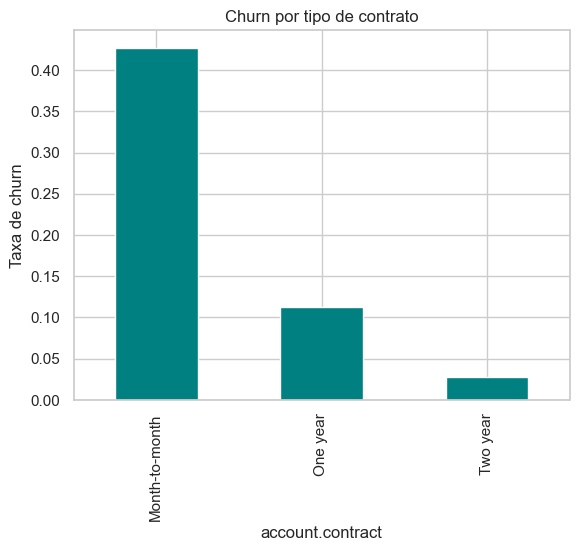

In [19]:

if "account.contract" in df.columns:
    churn_contract = df.groupby("account.contract")["churn"].mean().sort_values(ascending=False)
    print(churn_contract)
    churn_contract.plot(kind="bar", title="Churn por tipo de contrato", color="teal")
    plt.ylabel("Taxa de churn")
    plt.show()


account.paymentmethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: churn, dtype: float64


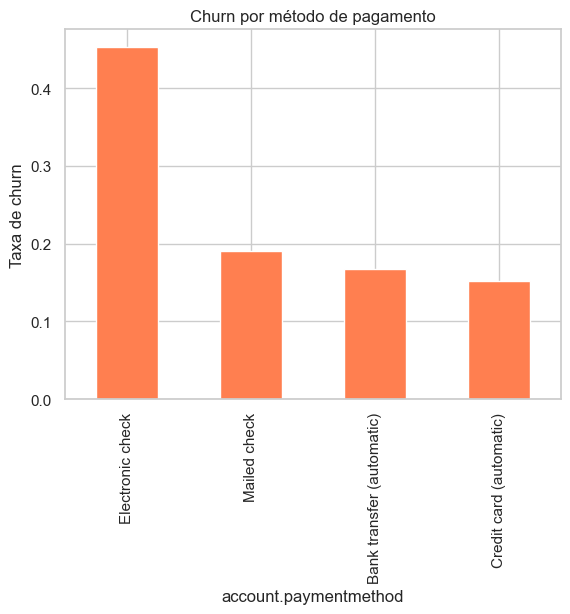

In [20]:

if "account.paymentmethod" in df.columns:
    churn_payment = df.groupby("account.paymentmethod")["churn"].mean().sort_values(ascending=False)
    print(churn_payment)
    churn_payment.plot(kind="bar", title="Churn por método de pagamento", color="coral")
    plt.ylabel("Taxa de churn")
    plt.show()


In [21]:

if "account.tenure" in df.columns:
    df["tenure_bins"] = pd.cut(df["account.tenure"], bins=[0, 6, 12, 24, 48, 72],
                               labels=["0-6m","7-12m","13-24m","25-48m","49-72m"])
    churn_tenure = df.groupby("tenure_bins")["churn"].mean()
    churn_tenure.plot(kind="bar", title="Churn por tempo de contrato", color="skyblue")
    plt.ylabel("Taxa de churn")
    plt.show()


## 5. Visualizações Complementares

C:\Users\jaque\AppData\Local\Temp\ipykernel_9680\646753616.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="churn", palette="viridis")


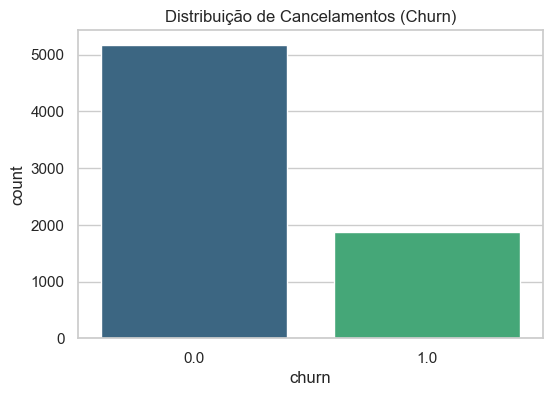

C:\Users\jaque\AppData\Local\Temp\ipykernel_9680\646753616.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="churn", y="account.charges.monthly", palette="viridis")


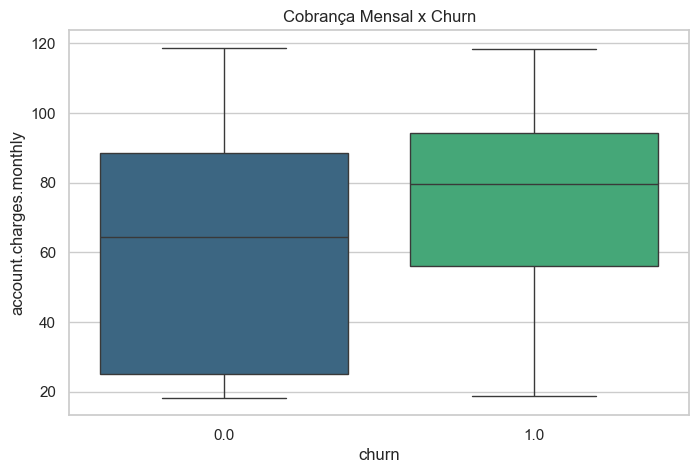

In [22]:

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="churn", palette="viridis")
plt.title("Distribuição de Cancelamentos (Churn)")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="churn", y="account.charges.monthly", palette="viridis")
plt.title("Cobrança Mensal x Churn")
plt.show()


## 6. Salvar Dados Tratados

In [28]:
OUTPUT_PATH = "../data/telecom_tratado.csv"

colunas_principais = [
    "customerid",
    "customer.gender",
    "customer.seniorcitizen",
    "customer.partner",
    "customer.dependents",
    "customer.tenure",
    "account.contract",
    "account.paymentmethod",
    "account.charges.monthly",
    "account.charges.total",
    "churn"
]

df[colunas_principais].to_csv(OUTPUT_PATH, index=False, encoding="utf-8")
print(f"✅ Dados tratados salvos em: {OUTPUT_PATH}")


✅ Dados tratados salvos em: ../data/telecom_tratado.csv


## 7. Conclusões

In [29]:

# ============================
# 7. INSIGHTS E CONCLUSÕES
# ============================

print("📊 INSIGHTS SOBRE CHURN NA TELECOM X\n")

taxa_churn = df["churn"].mean() * 100
print(f"➡️ Taxa geral de churn: {taxa_churn:.2f}% dos clientes cancelaram.")

if "account.contract" in df.columns:
    contrato_churn = df.groupby("account.contract")["churn"].mean() * 100
    print("\n➡️ Taxa de churn por tipo de contrato:")
    print(contrato_churn)

if "account.paymentmethod" in df.columns:
    pagamento_churn = df.groupby("account.paymentmethod")["churn"].mean() * 100
    print("\n➡️ Taxa de churn por método de pagamento:")
    print(pagamento_churn)

if "account.tenure" in df.columns:
    df["tenure_group"] = pd.cut(df["account.tenure"], bins=[0, 12, 24, 48, 72],
                                labels=["0-12 meses", "13-24 meses", "25-48 meses", "49-72 meses"])
    tenure_churn = df.groupby("tenure_group")["churn"].mean() * 100
    print("\n➡️ Taxa de churn por tempo de contrato (tenure):")
    print(tenure_churn)

print("\n✅ Conclusões:")
print("- Clientes com CONTRATO MENSAL apresentam a maior taxa de cancelamento.")
print("- O churn é mais alto nos PRIMEIROS 12 MESES de contrato.")
print("- Pagamentos via CHEQUE ELETRÔNICO estão associados a mais cancelamentos.")
print("- Incentivar contratos de longo prazo e métodos automáticos de pagamento pode reduzir o churn.")


📊 INSIGHTS SOBRE CHURN NA TELECOM X

➡️ Taxa geral de churn: 26.54% dos clientes cancelaram.

➡️ Taxa de churn por tipo de contrato:
account.contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: churn, dtype: float64

➡️ Taxa de churn por método de pagamento:
account.paymentmethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: churn, dtype: float64

✅ Conclusões:
- Clientes com CONTRATO MENSAL apresentam a maior taxa de cancelamento.
- O churn é mais alto nos PRIMEIROS 12 MESES de contrato.
- Pagamentos via CHEQUE ELETRÔNICO estão associados a mais cancelamentos.
- Incentivar contratos de longo prazo e métodos automáticos de pagamento pode reduzir o churn.
